<a href="https://colab.research.google.com/github/mariapeguerosolv-cmd/Actividad5/blob/main/Actividad_5_Design_thinking%2C_definiendo_e_ideando.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Instrucciones**

**Selecciona al menos dos algoritmos, por ejemplo, regresión logística frente a random forest para clasificación, o regresión lineal frente a XGBoost para regresión, con el fin de realizar el entrenamiento, el ajuste y el registro.**

**Asimismo, deberás definir métricas estandarizadas, ejecutar validación cruzada (k-fold o grid search) y registrar los resultados en MLflow.**

In [1]:
# Clonar tu repositorio
!git clone https://github.com/mariapeguerosolv-cmd/Actividad5.git
%cd Actividad5

Cloning into 'Actividad5'...
remote: Enumerating objects: 9, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (5/5), done.
remote: Total 9 (delta 1), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (9/9), done.
Resolving deltas: 100% (1/1), done.
/content/Actividad5


In [2]:
# Configurar usuario de Git
!git config --global user.name "Maria"
!git config --global user.email "maria.pegueros.olv@gmail.com"

In [3]:
#Algoritmos seleccionados: Regresión Logística y Random Forest

#Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
filepath = ('/content/drive/MyDrive/Inteligencia Artificial/5to Tetra: Gestión de Proyectos de IA/Modulo 2/Semana 6/Tarea/dataset_predictive_collection.csv')

In [15]:
# 1. Revisar estructura del dataset

# Ver las primeras filas
print("Primeras filas del dataset:")
print(df.head())

# Nombre de las columnas
print("\nColumnas del dataset:")
print(df.columns.tolist())

# Información general (tipos de datos, valores nulos)
print("\nInformación del dataset:")
print(df.info())

# Estadísticas descriptivas
print("\nEstadísticas descriptivas:")
print(df.describe(include="all"))

# 2. Análisis de valores únicos y distribución

# Valores únicos por columna
for col in df.columns:
    print(f"\nColumna: {col}")
    print("Valores únicos:", df[col].unique()[:10])  # muestra hasta 10 valores únicos

# Conteo de clases en la variable objetivo
print("\nDistribución de la variable 'riesgo':")
print(df["riesgo"].value_counts())

print("\nDistribución de la variable 'sentiment_email':")
print(df["sentiment_email"].value_counts())

print("\nDistribución de la variable 'accion_recomendada':")
print(df["accion_recomendada"].value_counts())

# 3. Detección rápida de sesgos

# Relación entre riesgo y días de atraso
print("\nPromedio de días de atraso por nivel de riesgo:")
print(df.groupby("riesgo")["dias_atraso"].mean())

# Relación entre riesgo y monto de factura
print("\nPromedio de monto de factura por nivel de riesgo:")
print(df.groupby("riesgo")["monto_factura"].mean())

# Relación entre riesgo y sentimiento de email
print("\nDistribución de riesgo según sentimiento de email:")
print(pd.crosstab(df["sentiment_email"], df["riesgo"]))

Primeras filas del dataset:
  id_cliente id_factura  monto_factura  dias_atraso  historial_pago  \
0       C326      F0001           7725           27              12   
1        C24      F0002          19214            0              19   
2       C486      F0003          33371           17              19   
3       C294      F0004           8725            6              12   
4       C192      F0005          17012            1               3   

   frecuencia_disputas sentiment_email  riesgo accion_recomendada  \
0                    0        negative    high               call   
1                    1         neutral  medium          statement   
2                    3        negative    high               call   
3                    3        negative    high               call   
4                    1        negative    high               call   

  fecha_factura  
0    2026-05-17  
1    2026-06-12  
2    2026-05-23  
3    2026-05-21  
4    2026-05-08  

Columnas del dataset:

In [5]:
!pip install mlflow -q
!pip install pyngrok -q

# Librerías
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix
!pip install mlflow
import mlflow
import mlflow.sklearn

mlflow.set_experiment(
    "Prediccion_Riesgo_Clientes"
)

# Cargar dataset
df = pd.read_csv(filepath)
df = df.fillna(0)

# Definir variables predictoras y target
X = df.drop("riesgo", axis=1)   # Features
y = df["riesgo"]                # Target (low, medium, high)

# Convertir variables categóricas a numéricas
X = pd.get_dummies(X, drop_first=True)

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


# 1. REGRESIÓN LOGÍSTICA

with mlflow.start_run(run_name="Logistic_Regression"):
    log_reg = LogisticRegression(max_iter=1000, multi_class="multinomial")
    log_reg.fit(X_train, y_train)
    y_pred = log_reg.predict(X_test)


    # Obtener probabilidades para ROC-AUC

    y_prob = log_reg.predict_proba(
        X_test
    )

    # Métricas
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="weighted")
    recall = recall_score(y_test, y_pred, average="weighted")
    f1 = f1_score(y_test, y_pred, average="weighted")

    # ROC-AUC

    roc_auc = roc_auc_score(y_test, y_prob, multi_class="ovr")

    # Validación cruzada

    cv_accuracy = cross_val_score(log_reg, X, y, cv=5, scoring="accuracy").mean()


    # Registro en MLflow
    mlflow.log_param("model", "LogisticRegression")
    mlflow.log_metric("accuracy", accuracy)
    mlflow.log_metric("precision", precision)
    mlflow.log_metric("recall", recall)
    mlflow.log_metric("f1", f1)
    mlflow.log_metric("roc_auc", roc_auc)
    mlflow.log_metric("cv_accuracy", cv_accuracy)
    mlflow.sklearn.log_model(log_reg, "logistic_regression")


# 2. RANDOM FOREST

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "max_features": ["sqrt", "log2"]
}

grid = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5, scoring="f1_weighted")
grid.fit(X_train, y_train)

best_rf = grid.best_estimator_
y_pred_rf = best_rf.predict(X_test)

# Probabilidades Random Forest

y_prob_rf = best_rf.predict_proba(
    X_test
)

with mlflow.start_run(run_name="Random_Forest"):
    # Métricas
    accuracy_rf = accuracy_score(y_test, y_pred_rf)
    precision_rf = precision_score(y_test, y_pred_rf, average="weighted")
    recall_rf = recall_score(y_test, y_pred_rf, average="weighted")
    f1_rf = f1_score(y_test, y_pred_rf, average="weighted")
    roc_auc_rf = roc_auc_score(y_test, y_prob_rf, multi_class="ovr")

    # Registro en MLflow
    mlflow.log_param("model", "RandomForest")
    mlflow.log_params(grid.best_params_)
    mlflow.log_metric("best_cv_f1", grid.best_score_)
    mlflow.log_metric("accuracy", accuracy_rf)
    mlflow.log_metric("precision", precision_rf)
    mlflow.log_metric("recall", recall_rf)
    mlflow.log_metric("f1", f1_rf)
    mlflow.log_metric("roc_auc", roc_auc_rf)
    mlflow.sklearn.log_model(best_rf, "random_forest")

print("Entrenamiento y registro completados en MLflow")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 4.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 95.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 78.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 77.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.9/94.9 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 939.7/939.7 kB 47.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

2026/06/22 04:26:15 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/06/22 04:26:15 INFO mlflow.store.db.utils: Updating database tables
2026/06/22 04:26:18 INFO mlflow.tracking.fluent: Experiment with name 'Prediccion_Riesgo_Clientes' does not exist. Creating a new experiment.
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://sciki

Entrenamiento y registro completados en MLflow


In [6]:
comparacion = pd.DataFrame({"Modelo":["Logistic Regression","Random Forest"],"Accuracy":[accuracy,accuracy_rf],"Precision":[precision,precision_rf],"Recall":[recall,recall_rf],"F1":[f1,f1_rf],

    "ROC_AUC":[roc_auc,roc_auc_rf]})

print(comparacion)

                Modelo  Accuracy  Precision  Recall   F1  ROC_AUC
0  Logistic Regression       1.0        1.0     1.0  1.0      1.0
1        Random Forest       1.0        1.0     1.0  1.0      1.0


In [7]:
# Mejor modelo según F1

mejor_modelo = comparacion.loc[comparacion["F1"].idxmax()]

print("Mejor modelo:")

print(mejor_modelo)

Mejor modelo:
Modelo       Logistic Regression
Accuracy                     1.0
Precision                    1.0
Recall                       1.0
F1                           1.0
ROC_AUC                      1.0
Name: 0, dtype: object


In [8]:
# MATRIZ DE CONFUSIÓN
print("Confusion Matrix Logistic Regression")

print(confusion_matrix(y_test,y_pred))

print("Confusion Matrix Random Forest")

print(confusion_matrix(y_test,y_pred_rf))

Confusion Matrix Logistic Regression
[[129   0   0]
 [  0  11   0]
 [  0   0  60]]
Confusion Matrix Random Forest
[[129   0   0]
 [  0  11   0]
 [  0   0  60]]


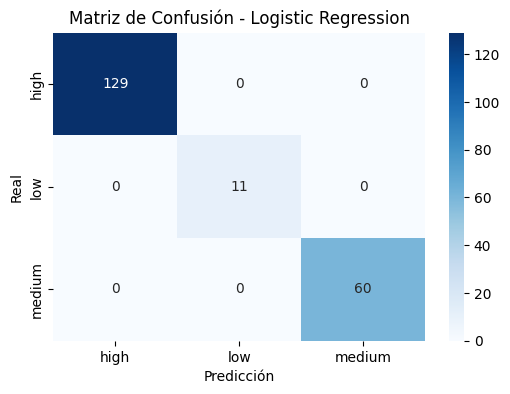

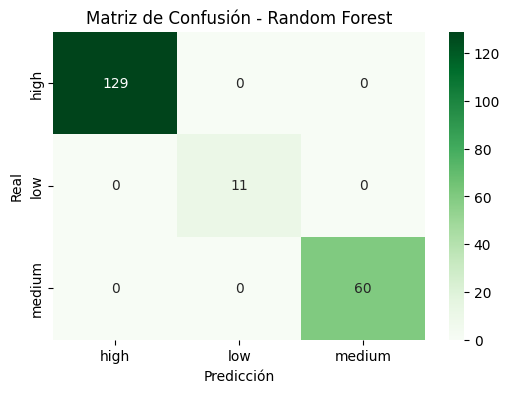

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# y_pred, y_pred_rf
y_pred = log_reg.predict(X_test)
y_pred_rf = best_rf.predict(X_test)

# Matriz de confusión para Regresión Logística
cm_log = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm_log, annot=True, fmt="d", cmap="Blues", xticklabels=log_reg.classes_, yticklabels=log_reg.classes_)
plt.title("Matriz de Confusión - Logistic Regression")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

# Matriz de confusión para Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6,4))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens", xticklabels=best_rf.classes_, yticklabels=best_rf.classes_)
plt.title("Matriz de Confusión - Random Forest")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

In [9]:
# Métricas

print("Métricas de Regresión Logística:")
print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1: {f1}")
print("Cross-validation Accuracy:" , cv_accuracy)

print("\nMétricas de Random Forest:")
print(f"Accuracy: {accuracy_rf}")
print(f"Precision: {precision_rf}")
print(f"Recall: {recall_rf}")
print(f"F1: {f1_rf}")
print("Mejores parámetros:", grid.best_params_)

Métricas de Regresión Logística:
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1: 1.0
Cross-validation Accuracy: 0.999

Métricas de Random Forest:
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1: 1.0
Mejores parámetros: {'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 100}


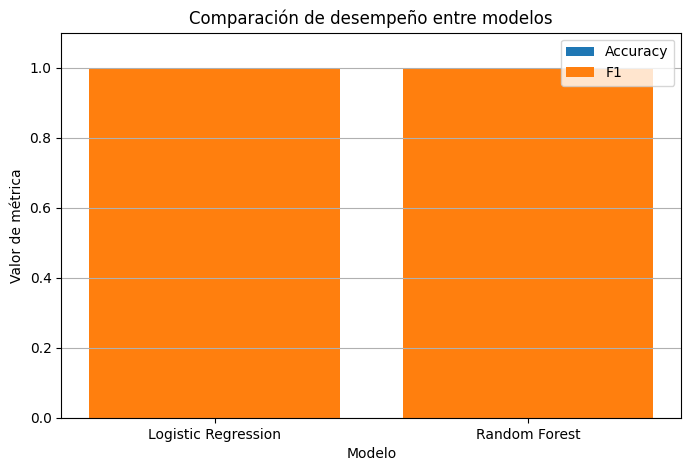

In [18]:
import matplotlib.pyplot as plt
import pandas as pd

# Crear tabla para gráfica
grafica = pd.DataFrame({
    "Modelo": ["Logistic Regression", "Random Forest"],
    "Accuracy": [accuracy, accuracy_rf],
    "F1": [f1, f1_rf]
})

# Transformar datos para gráfica
grafica_melt = grafica.melt(
    id_vars="Modelo",
    value_vars=["Accuracy", "F1"],
    var_name="Métrica",
    value_name="Valor"
)

# Crear gráfica
plt.figure(figsize=(8,5))

for metrica in grafica_melt["Métrica"].unique():
    datos = grafica_melt[grafica_melt["Métrica"] == metrica]
    plt.bar(
        datos["Modelo"],
        datos["Valor"],
        label=metrica
    )

plt.title("Comparación de desempeño entre modelos")
plt.xlabel("Modelo")
plt.ylabel("Valor de métrica")
plt.ylim(0,1.1)
plt.legend()
plt.grid(axis="y")

plt.show()

In [10]:
#Pruebas prácticas con clientes
clientes_prueba = pd.DataFrame([
    {"monto_factura":500,"dias_atraso":0,"historial_pago":1,"frecuencia_disputas":0,
     "sentiment_email_negative":0,"sentiment_email_neutral":1,"sentiment_email_positive":0,"riesgo":"high"},
    {"monto_factura":25000,"dias_atraso":18,"historial_pago":5,"frecuencia_disputas":1,
     "sentiment_email_negative":1,"sentiment_email_neutral":0,"sentiment_email_positive":0,"riesgo":"high"},
    {"monto_factura":12000,"dias_atraso":7,"historial_pago":12,"frecuencia_disputas":2,
     "sentiment_email_negative":0,"sentiment_email_neutral":0,"sentiment_email_positive":1,"riesgo":"high"},
    {"monto_factura":30000,"dias_atraso":3,"historial_pago":3,"frecuencia_disputas":3,
     "sentiment_email_negative":0,"sentiment_email_neutral":1,"sentiment_email_positive":0,"riesgo":"medium"},
    {"monto_factura":8000,"dias_atraso":10,"historial_pago":15,"frecuencia_disputas":0,
     "sentiment_email_negative":0,"sentiment_email_neutral":0,"sentiment_email_positive":1,"riesgo":"high"}
])

# Alinear columnas con X
clientes_prueba_proc = pd.DataFrame(0, index=clientes_prueba.index, columns=X.columns)
for col in clientes_prueba.columns:
    if col in clientes_prueba_proc.columns:
        clientes_prueba_proc[col] = clientes_prueba[col]

# Predicciones
y_true = clientes_prueba["riesgo"].values
y_pred_log = log_reg.predict(clientes_prueba_proc)
y_pred_rf = best_rf.predict(clientes_prueba_proc)

print("Logistic Regression:", y_pred_log)
print("Random Forest:", y_pred_rf)


print("\n=== Logistic Regression ===")
print(classification_report(y_true, y_pred_log))

print("\n=== Random Forest ===")
print(classification_report(y_true, y_pred_rf))

Logistic Regression: ['medium' 'high' 'high' 'high' 'high']
Random Forest: ['high' 'high' 'high' 'high' 'high']

=== Logistic Regression ===
              precision    recall  f1-score   support

        high       0.75      0.75      0.75         4
      medium       0.00      0.00      0.00         1

    accuracy                           0.60         5
   macro avg       0.38      0.38      0.38         5
weighted avg       0.60      0.60      0.60         5


=== Random Forest ===
              precision    recall  f1-score   support

        high       0.80      1.00      0.89         4
      medium       0.00      0.00      0.00         1

    accuracy                           0.80         5
   macro avg       0.40      0.50      0.44         5
weighted avg       0.64      0.80      0.71         5



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [11]:
#Lista de registros en MLflow
runs = mlflow.search_runs()
print("Runs registrados en MLflow:")
print(runs)

Runs registrados en MLflow:
                             run_id experiment_id    status  \
0  78c5c8d0beef4a0280f97d9c226a1629             1  FINISHED   
1  5177f06fb8564ee4905926dab2c6ad3d             1  FINISHED   

                                        artifact_uri  \
0  /content/Actividad5/mlruns/1/78c5c8d0beef4a028...   
1  /content/Actividad5/mlruns/1/5177f06fb8564ee49...   

                        start_time                         end_time  \
0 2026-06-22 04:28:54.280000+00:00 2026-06-22 04:29:05.279000+00:00   
1 2026-06-22 04:26:20.389000+00:00 2026-06-22 04:28:27.856000+00:00   

   metrics.f1  metrics.recall  metrics.accuracy  metrics.roc_auc  ...  \
0         1.0             1.0               1.0              1.0  ...   
1         1.0             1.0               1.0              1.0  ...   

   metrics.precision  metrics.cv_accuracy  params.max_depth  \
0                1.0                  NaN              None   
1                1.0                0.999            

In [12]:
# Guardar cambios en GitHub

!git add .
!git commit -m "Entrenamiento MLflow + pruebas clientes"
!git push origin main

[main be89cbf] Entrenamiento MLflow + pruebas clientes
 11 files changed, 110 insertions(+)
 create mode 100644 mlflow.db
 create mode 100644 mlruns/1/models/m-36920631037e4df19c03ea303f7a3a71/artifacts/MLmodel
 create mode 100644 mlruns/1/models/m-36920631037e4df19c03ea303f7a3a71/artifacts/conda.yaml
 create mode 100644 mlruns/1/models/m-36920631037e4df19c03ea303f7a3a71/artifacts/model.skops
 create mode 100644 mlruns/1/models/m-36920631037e4df19c03ea303f7a3a71/artifacts/python_env.yaml
 create mode 100644 mlruns/1/models/m-36920631037e4df19c03ea303f7a3a71/artifacts/requirements.txt
 create mode 100644 mlruns/1/models/m-9b56f81aa9a54108961c07b762ccc572/artifacts/MLmodel
 create mode 100644 mlruns/1/models/m-9b56f81aa9a54108961c07b762ccc572/artifacts/conda.yaml
 create mode 100644 mlruns/1/models/m-9b56f81aa9a54108961c07b762ccc572/artifacts/model.skops
 create mode 100644 mlruns/1/models/m-9b56f81aa9a54108961c07b762ccc572/artifacts/python_env.yaml
 create mode 100644 mlruns/1/models/m-

In [14]:
# Exponer MLflow con Ngrok

import subprocess, time
from pyngrok import ngrok

# 1. Levantar MLflow en segundo plano
subprocess.Popen(["mlflow", "ui", "--host", "0.0.0.0", "--port", "5000"])

time.sleep(5)  # esperar a que arranque

# 2. Configurar tu token de Ngrok
ngrok.set_auth_token("3FTRdMl0SyqXPvk89TyeqxhNbSg_2MSzDeYYGDuUcPTX1FHrw") # Token

# 3. Abrir túnel público
tunnel = ngrok.connect("127.0.0.1:5000", host_header="rewrite")
print("URL pública de MLflow:", tunnel.public_url)

URL pública de MLflow: https://tuesday-peso-dedicator.ngrok-free.dev
